# Modelo predictivo basado en MobileNet v3

In [ ]:
# google drive
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch
from torchvision import models
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.nn import CrossEntropyLoss

In [34]:
model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
model.classifier[3] = torch.nn.Linear(model.classifier[3].in_features, 2)

In [31]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model.to(device)

cuda


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [3]:
# !ls 'drive/MyDrive/cherry_disease'
# PATH= 'drive/MyDrive/cherry_disease'

PATH = "../dataset"

In [5]:
# preprocesamiento de las imagenes

preprocessing = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]
)
])

In [6]:
# cargar conjuntos
train_folder = ImageFolder(f"{PATH}/train", transform = preprocessing)
val_folder = ImageFolder(f"{PATH}/val", transform = preprocessing)

train_loader = DataLoader(train_folder, batch_size = 12, shuffle = True)
val_loader = DataLoader(val_folder, batch_size = 12, shuffle = True)
train_loader, val_loader

(<torch.utils.data.dataloader.DataLoader at 0x78d180a23e00>,
 <torch.utils.data.dataloader.DataLoader at 0x78d180c8c1d0>)

In [37]:
for params in model.parameters():
    params.requires_grad = False

In [38]:
# reemplazar la ultima capa (3), en una que retorne 2 predicciónes
model.classifier[3] = torch.nn.Linear(model.classifier[3].in_features, 2)

____
# Loop de entrenamiento

In [39]:
# funcion de perdida
loss_fn = CrossEntropyLoss()

# se utiliza optimizador Adam
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [40]:
model.to(device)
train_losses = []
val_losses = []
epochs = 5
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        y_prob = model(inputs)
        loss = loss_fn(y_prob, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    # Promediar datos de entrenamiento
    train_loss = train_loss / len(train_loader)
    train_losses.append(train_loss)
    model.eval()
    val_loss = 0
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        y_prob = model(inputs)
        loss = loss_fn(y_prob, labels)
        val_loss += loss.item()
    # Promediar datos de validación
    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)
    print(f"Epoch {epoch}, Train Loss: {train_loss}, Val Loss: {val_loss}")

Epoch 0, Train Loss: 0.15909745453245705, Val Loss: 0.08757813321426511
Epoch 1, Train Loss: 0.06442594935651869, Val Loss: 0.01833754344988847
Epoch 2, Train Loss: 0.029276554296302493, Val Loss: 0.011740262441890081
Epoch 3, Train Loss: 0.026620650351105724, Val Loss: 0.010495190352230566
Epoch 4, Train Loss: 0.021710669634103397, Val Loss: 0.008265041440608911


### Métricas

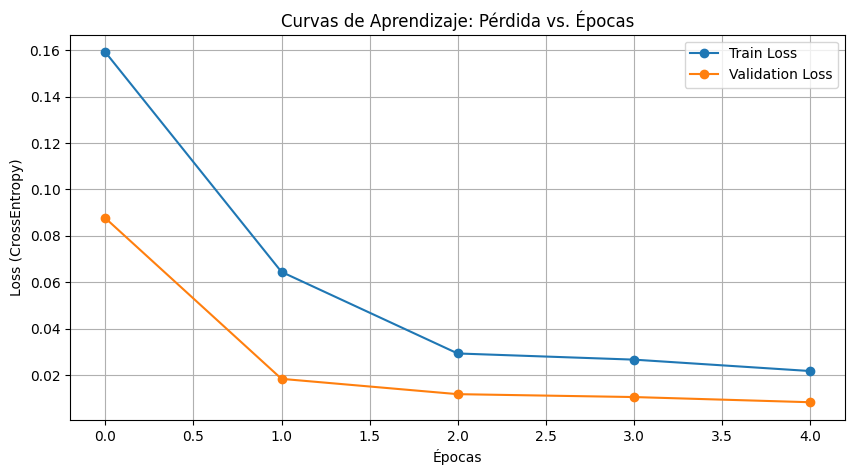

In [ ]:
# grafico de perdidas

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Curvas de Aprendizaje: Pérdida vs. Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss (CrossEntropy)')
plt.legend()
plt.grid(True)
plt.show()

In [42]:
# para métricas
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)

        outputs = model(inputs)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

--- Reporte de Clasificación ---
                      precision    recall  f1-score   support

      Clase 0 (Sano)       1.00      1.00      1.00       210
Clase 1 (Blanquilla)       1.00      0.99      1.00       170

            accuracy                           1.00       380
           macro avg       1.00      1.00      1.00       380
        weighted avg       1.00      1.00      1.00       380



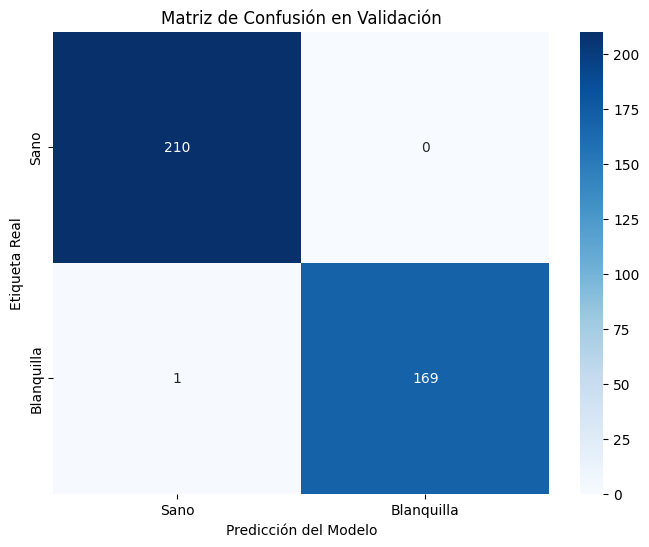

In [ ]:
print("--- Reporte de Clasificación ---")
print(classification_report(y_true, y_pred, target_names=['Clase 0 (Sano)', 'Clase 1 (Blanquilla)']))

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sano', 'Blanquilla'],
            yticklabels=['Sano', 'Blanquilla'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión en Validación')
plt.show()

### Visualización de predicción

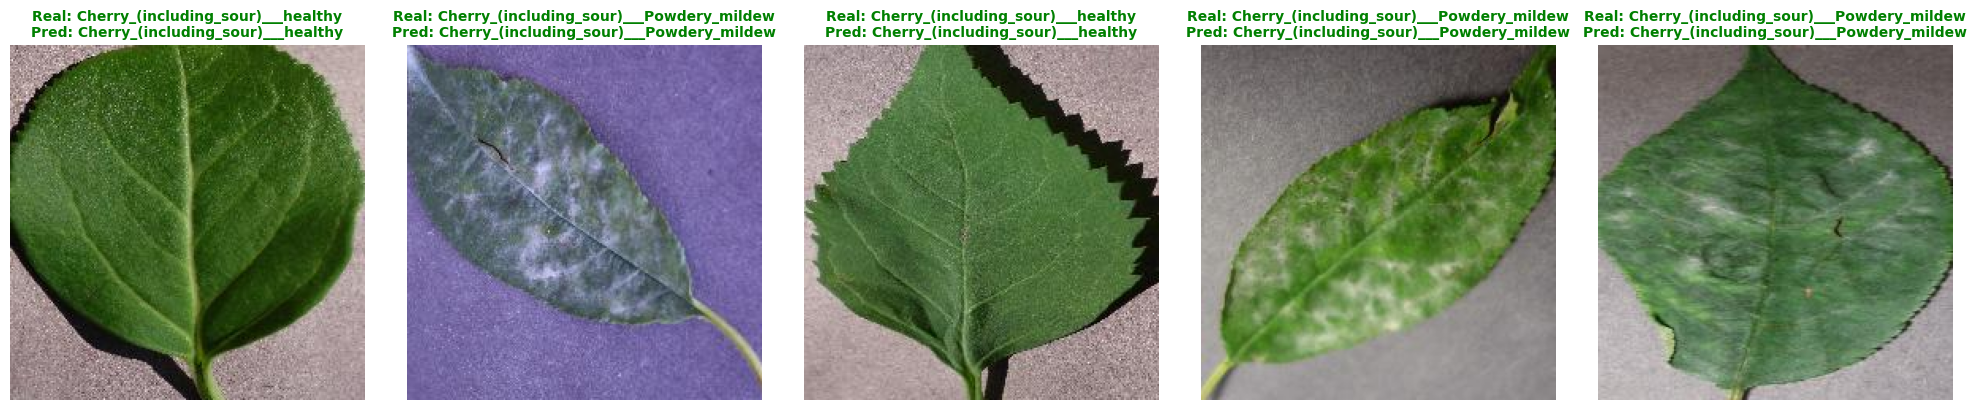

In [ ]:
model.eval()

# extraer un lote del conjunto de validación
dataiter = iter(val_loader)
inputs, labels = next(dataiter)

# obtener nombres de las clases
class_names = val_folder.classes

# num de imágenes a mostrar
num_images = min(5, len(inputs))

# seleccionar imagenes aleatorias sin repetir
indices = random.sample(range(len(inputs)), num_images)

# Crear figura
fig, axes = plt.subplots(1, num_images, figsize=(4 * num_images, 4))

# Si solo hay una imagen, convertir axes en lista
if num_images == 1:
    axes = [axes]

# params de desnormalización
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

with torch.no_grad():
    for ax, idx in zip(axes, indices):

        img_tensor = inputs[idx]
        true_label = labels[idx].item()

        # predicción
        img_input = img_tensor.unsqueeze(0).to(device)
        output = model(img_input)
        pred_label = output.argmax(dim=1).item()

        # visualización
        img_display = img_tensor.cpu().numpy().transpose((1, 2, 0))
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1)

        ax.imshow(img_display)

        color = "green" if true_label == pred_label else "red"

        ax.set_title(
            f"Real: {class_names[true_label]}\nPred: {class_names[pred_label]}",
            color=color,
            fontsize=10,
            fontweight="bold"
        )

        ax.axis("off")

plt.tight_layout()
plt.show()

____
#### Guardar pesos del modelo

In [46]:
torch.save(model.state_dict(), 'mobilenetv3_large_predictor.pth')